# Phân tích Sự cân bằng các lớp (Class Distribution)

Notebook này tập trung vào việc phân tích sự phân bổ của các loại cảm xúc trong bộ dữ liệu FER2013. Việc hiểu rõ sự cân bằng giữa các lớp là cực kỳ quan trọng để:
1. Quyết định chiến lược training (Class Weights).
2. Áp dụng Data Augmentation phù hợp.
3. Đánh giá khách quan hiệu năng của model.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Cấu hình thẩm mỹ cho biểu đồ
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)

EMOTIONS_MAP = {
    0: 'Angry', 
    1: 'Disgust', 
    2: 'Fear', 
    3: 'Happy', 
    4: 'Sad', 
    5: 'Surprise', 
    6: 'Neutral'
}

DATA_DIR = "../../data/fer_data/"
df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
df_val = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
df_test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

## 1. Biểu đồ cột (Bar Chart) - Số lượng mẫu
Chúng ta sẽ đếm số lượng ảnh cho mỗi cảm xúc trong cả 3 tập dữ liệu.

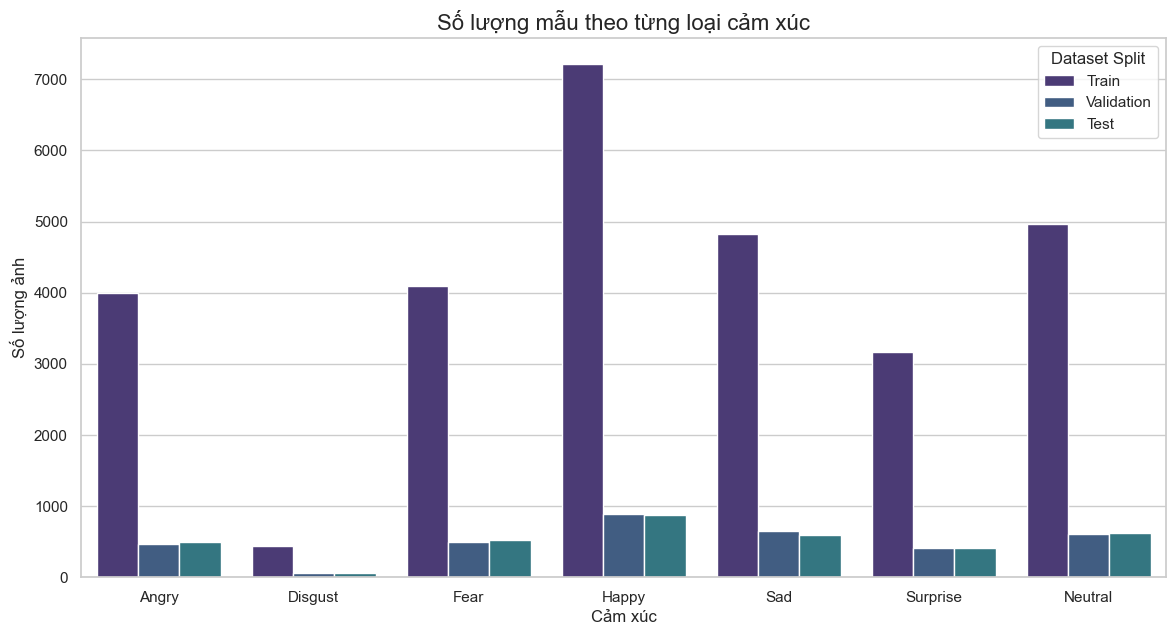

In [6]:
def get_counts(df, name):
    counts = df['emotion'].value_counts().sort_index().reset_index()
    counts.columns = ['emotion', 'count']
    counts['label'] = counts['emotion'].map(EMOTIONS_MAP)
    counts['split'] = name
    return counts

df_counts = pd.concat([
    get_counts(df_train, 'Train'),
    get_counts(df_val, 'Validation'),
    get_counts(df_test, 'Test')
])

plt.figure(figsize=(14, 7))
sns.barplot(data=df_counts, x='label', y='count', hue='split')
plt.title("Số lượng mẫu theo từng loại cảm xúc", fontsize=16)
plt.xlabel("Cảm xúc", fontsize=12)
plt.ylabel("Số lượng ảnh", fontsize=12)
plt.legend(title="Dataset Split")
plt.show()

## 2. Phân tích tỉ lệ phần trăm (%)
Tỉ lệ phần trăm giúp ta thấy rõ mức độ mất cân bằng mà không bị ảnh hưởng bởi kích thước tuyệt đối của mỗi tập.

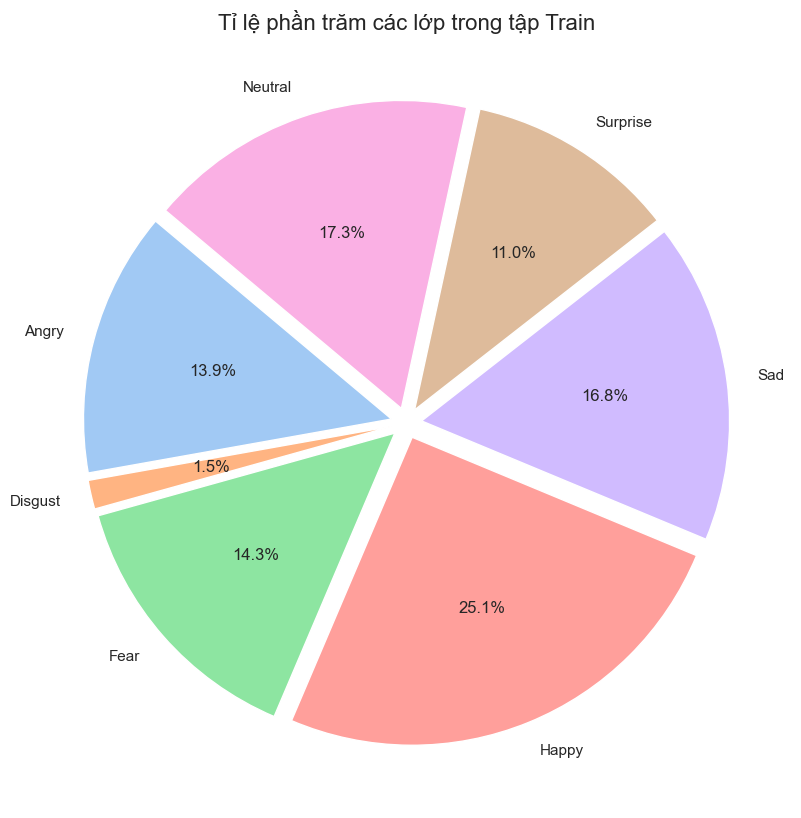

In [7]:
train_pct = df_train['emotion'].value_counts(normalize=True).sort_index() * 100
labels = [EMOTIONS_MAP[i] for i in train_pct.index]

plt.figure(figsize=(10, 10))
plt.pie(train_pct, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette("pastel"), explode=[0.05]*7)
plt.title("Tỉ lệ phần trăm các lớp trong tập Train", fontsize=16)
plt.show()

## 3. Phát hiện Mất cân bằng (Imbalance Detection)
Nhìn vào biểu đồ trên, ta thấy:
- **Lớp mạnh nhất**: **Happy** (thường chiếm >20%).
- **Lớp yếu nhất**: **Disgust** (thường chỉ chiếm <2%).

Sự chênh lệch này có thể khiến model thiên vị (bias) về phía các lớp nhiều dữ liệu và bỏ qua các lớp ít dữ liệu.

## 4. Đề xuất Giải pháp
Để giải quyết vấn đề này, chúng ta có thể áp dụng hai phương pháp chính:

### A. Tính toán Class Weights
Class weights sẽ gán trọng số cao hơn cho các lớp ít mẫu trong hàm loss.

In [8]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(df_train['emotion'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=df_train['emotion'])
weights_dict = {EMOTIONS_MAP[i]: f"{w:.2f}" for i, w in zip(classes, weights)}

print("Trọng số gợi ý cho các lớp (Class Weights):")
for label, weight in weights_dict.items():
    print(f"- {label:10}: {weight}")

Trọng số gợi ý cho các lớp (Class Weights):
- Angry     : 1.03
- Disgust   : 9.41
- Fear      : 1.00
- Happy     : 0.57
- Sad       : 0.85
- Surprise  : 1.29
- Neutral   : 0.83


### B. Data Augmentation
- Đối với các lớp như **Disgust**, ta cần áp dụng các phép biến đổi ảnh mạnh hơn (xoay, lật, thay đổi độ sáng) để tạo thêm dữ liệu giả lập.
- Sử dụng Oversampling cho các lớp thiểu số trong quá trình load data.